# 初始参数配置

In [15]:
# ============================================
# Jupyter Script: GP 自动挖掘 + 过滤 + 保存
# ============================================

from factors.factor_auto_search import GeneticFactorGenerator
import pandas as pd

# 1) 初始化 GeneticFactorGenerator（基于你给的参数）
fg = GeneticFactorGenerator(
    instrument_id_list='C0',
    start_time='20200101',
    end_time='20241231',
    version='20260403_gp_test',
    calculate_baseline=True,
    max_factor_count=50,
    rolling_norm_clip=5.0,  # 限制最大杠杆比
    gp_generations=30,
    fitness_metric='ic',
    gp_max_depth=4,
    gp_population_size=150,  # 每轮生成的因子数量
    gp_elite_size=30,        # 每轮前gp_elite_size个因子直接保留（不变异）进入下一轮
    gp_elite_relative_threshold=0.75,
    gp_crossover_prob=0.7,
    gp_leaf_prob=0.3,
    gp_const_prob=0.02,
    gp_window_choices=[5, 10, 20],
    gp_depth_penalty_coef=0.0,
    gp_depth_penalty_start_depth=4,
    gp_depth_penalty_linear_coef=0.05,
    gp_depth_penalty_quadratic_coef=0.0,
    gp_early_stopping_generation_count=20,
    random_seed=None,
    # 新增参数（你要求）
    gp_assumed_initial_capital=100000,
    gp_small_factor_penalty_coef=0.0,
    gp_elite_stagnation_generation_count=5,
    gp_max_shock_generation=3,

)

# 2) 过滤阈值（沿用项目内日常脚本的默认思路）
filter_indicator_dict = {
    'Net Return': (0.05, 0.03, 1),
    'Net Sharpe': (0.5, 0.3, 1),
}

# 3) 一键执行：自动挖掘 + 筛选 + 保存
result = fg.auto_mine_select_and_save_fc(
    filter_indicator_dict=filter_indicator_dict,
    n_jobs=5,
    require_all_row=True,
    require_all_instruments=True,
)

# 4) 查看结果
print("config_path:", result.get("config_path"))
print("selected_count:", len(result.get("selected_fc_name_list", [])))
print("selected_fc_name_list:", result.get("selected_fc_name_list", []))

bt = result.get("bt")
if bt is not None and getattr(bt, "performance_summary", None) is not None:
    print("\nperformance_summary tail:")
    display(bt.performance_summary.tail(10))

/Users/wenglongao/anaconda3/envs/future/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/wenglongao/anaconda3/envs/future/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


config_path: None
selected_count: 0
selected_fc_name_list: []

performance_summary tail:


,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2022,0.028600,-0.037152,0.142901,0.142853,0.200142,-0.260070,0.235303,-0.312511,0.120816,0.161368,...,"0.161368(0.15486,0.122289)","0.200142(0.267796,-0.267796)","-0.26007(0.267796,-0.267796)","0.504132(0.516529,0.466942)","0.466942(0.516529,0.466942)","1.30461(0,0)",fac_gp_0049,1d,0.0002,C0
2023,0.088478,0.027714,0.113310,0.113257,0.780850,0.244700,0.958965,0.304445,0.079918,0.095157,...,"0.0951571(0.146334,0.115003)","0.78085(-1.08921,1.08921)","0.2447(-1.08921,1.08921)","0.454545(0.483471,0.491736)","0.442149(0.483471,0.491736)","1.20563(0,0)",fac_gp_0049,1d,0.0002,C0
2024,-0.248167,-0.309813,0.124829,0.125537,-1.988045,-2.467897,-1.903598,-2.429764,0.247195,0.287876,...,"0.287876(0.176943,0.0575955)","-1.98804(-1.37663,1.37663)","-2.4679(-1.37663,1.37663)","0.471074(0.417355,0.541322)","0.454545(0.417355,0.541322)","1.22314(0,0)",fac_gp_0049,1d,0.0002,C0
all,0.027995,-0.033461,0.126634,0.126761,0.221068,-0.263970,0.265860,-0.322287,0.247195,0.344604,...,"0.344604(0.30725,0.362493)","0.221068(0.176769,-0.176769)","-0.26397(0.176421,-0.177116)","0.471947(0.495875,0.480198)","0.450495(0.495875,0.480198)","1.21937(0.000825083,0.000825083)",fac_gp_0049,1d,0.0002,C0
2020,0.010397,-0.049843,0.122264,0.122306,0.085035,-0.407529,0.120762,-0.581114,0.097038,0.123665,...,"0.123665(0.0487138,0.291679)","0.085035(2.75956,-2.75956)","-0.407529(2.75777,-2.76134)","0.411523(0.563786,0.411523)","0.386831(0.563786,0.411523)","1.19524(0.00411523,0.00411523)",fac_gp_0050,1d,0.0002,C0
2021,0.259780,0.200887,0.126989,0.126968,2.045688,1.582189,2.977077,2.305838,0.058819,0.070962,...,"0.0709618(0.148106,0.111244)","2.04569(0.0391665,-0.0391665)","1.58219(0.0391665,-0.0391665)","0.518519(0.497942,0.489712)","0.502058(0.497942,0.489712)","1.16852(0,0)",fac_gp_0050,1d,0.0002,C0
2022,0.028600,-0.037152,0.142901,0.142853,0.200142,-0.260070,0.235303,-0.312511,0.120816,0.161368,...,"0.161368(0.15486,0.122289)","0.200142(0.267796,-0.267796)","-0.26007(0.267796,-0.267796)","0.504132(0.516529,0.466942)","0.466942(0.516529,0.466942)","1.30461(0,0)",fac_gp_0050,1d,0.0002,C0
2023,0.088478,0.027714,0.113310,0.113257,0.780850,0.244700,0.958965,0.304445,0.079918,0.095157,...,"0.0951571(0.146334,0.115003)","0.78085(-1.08921,1.08921)","0.2447(-1.08921,1.08921)","0.454545(0.483471,0.491736)","0.442149(0.483471,0.491736)","1.20563(0,0)",fac_gp_0050,1d,0.0002,C0
2024,-0.248167,-0.309813,0.124829,0.125537,-1.988045,-2.467897,-1.903598,-2.429764,0.247195,0.287876,...,"0.287876(0.176943,0.0575955)","-1.98804(-1.37663,1.37663)","-2.4679(-1.37663,1.37663)","0.471074(0.417355,0.541322)","0.454545(0.417355,0.541322)","1.22314(0,0)",fac_gp_0050,1d,0.0002,C0


In [16]:
import random
rng = random.Random(None)
rng.random()

0.20076583099745104

# 提高随机性参数配置

In [1]:
# ============================================
# Jupyter Script: GP 自动挖掘 + 过滤 + 保存
# ============================================

from factors.factor_auto_search import GeneticFactorGenerator
import pandas as pd

# 1) 初始化 GeneticFactorGenerator（基于你给的参数）
fg = GeneticFactorGenerator(
    instrument_id_list='C0',
    start_time='20200101',
    end_time='20241231',
    version='20260403_gp_test_2',
    calculate_baseline=True,
    max_factor_count=50,
    rolling_norm_clip=5.0,  # 限制最大杠杆比
    gp_generations=60,
    fitness_metric='ic',
    gp_max_depth=6,
    gp_population_size=300,  # 每轮生成的因子数量
    gp_elite_size=20,        # 每轮前gp_elite_size个因子直接保留（不变异）进入下一轮
    gp_elite_relative_threshold=0.65,
    gp_crossover_prob=0.5,
    gp_leaf_prob=0.2,
    gp_const_prob=0.02,
    gp_mutation_prob=0.5,
    gp_tournament_size=4,
    gp_window_choices=[3, 5, 10, 20, 30],
    gp_depth_penalty_coef=0.0,
    gp_depth_penalty_start_depth=6,
    gp_depth_penalty_linear_coef=0.03,
    gp_depth_penalty_quadratic_coef=0.0,
    gp_early_stopping_generation_count=20,
    random_seed=None,
    # 新增参数（你要求）
    gp_assumed_initial_capital=100000,
    gp_small_factor_penalty_coef=0.0,
    gp_elite_stagnation_generation_count=4,
    gp_max_shock_generation=3,

)

# 2) 过滤阈值（沿用项目内日常脚本的默认思路）
filter_indicator_dict = {
    'Net Return': (0.05, 0.03, 1),
    'Net Sharpe': (0.5, 0.3, 1),
}

# 3) 一键执行：自动挖掘 + 筛选 + 保存
result = fg.auto_mine_select_and_save_fc(
    filter_indicator_dict=filter_indicator_dict,
    n_jobs=5,
    require_all_row=True,
    require_all_instruments=True,
)

# 4) 查看结果
print("config_path:", result.get("config_path"))
print("selected_count:", len(result.get("selected_fc_name_list", [])))
print("selected_fc_name_list:", result.get("selected_fc_name_list", []))

bt = result.get("bt")
if bt is not None and getattr(bt, "performance_summary", None) is not None:
    print("\nperformance_summary tail:")
    display(bt.performance_summary.tail(10))

/Users/wenglongao/work_repo/lionet/factors/factor_ops.py:816: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  s = s.pct_change(1)
/Users/wenglongao/work_repo/lionet/factors/factor_ops.py:816: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  s = s.pct_change(1)
/Users/wenglongao/work_repo/lionet/factors/factor_ops.py:816: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  s = s.pct_change(1)
/Users/wenglongao/w

config_path: factors.genetic_programming@20260403_gp_test_1
selected_count: 49
selected_fc_name_list: ['fac_gp_0001', 'fac_gp_0002', 'fac_gp_0003', 'fac_gp_0004', 'fac_gp_0005', 'fac_gp_0006', 'fac_gp_0007', 'fac_gp_0008', 'fac_gp_0009', 'fac_gp_0010', 'fac_gp_0012', 'fac_gp_0013', 'fac_gp_0014', 'fac_gp_0015', 'fac_gp_0016', 'fac_gp_0017', 'fac_gp_0018', 'fac_gp_0019', 'fac_gp_0020', 'fac_gp_0021', 'fac_gp_0022', 'fac_gp_0023', 'fac_gp_0024', 'fac_gp_0025', 'fac_gp_0026', 'fac_gp_0027', 'fac_gp_0028', 'fac_gp_0029', 'fac_gp_0030', 'fac_gp_0031', 'fac_gp_0032', 'fac_gp_0033', 'fac_gp_0034', 'fac_gp_0035', 'fac_gp_0036', 'fac_gp_0037', 'fac_gp_0038', 'fac_gp_0039', 'fac_gp_0040', 'fac_gp_0041', 'fac_gp_0042', 'fac_gp_0043', 'fac_gp_0044', 'fac_gp_0045', 'fac_gp_0046', 'fac_gp_0047', 'fac_gp_0048', 'fac_gp_0049', 'fac_gp_0050']

performance_summary tail:


,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2022,0.216450,0.158714,0.140765,0.140298,1.537663,1.131266,1.852995,1.392487,0.090567,0.101365,...,"0.101365(0.15486,0.122289)","1.53766(0.267796,-0.267796)","1.13127(0.267796,-0.267796)","0.528926(0.516529,0.466942)","0.491736(0.516529,0.466942)","1.14555(0,0)",fac_gp_0049,1d,0.0002,C0
2023,0.143030,0.079176,0.109512,0.108610,1.306067,0.728990,1.522846,0.867711,0.055703,0.060699,...,"0.060699(0.146334,0.115003)","1.30607(-1.08921,1.08921)","0.72899(-1.08921,1.08921)","0.533058(0.483471,0.491736)","0.512397(0.483471,0.491736)","1.26696(0,0)",fac_gp_0049,1d,0.0002,C0
2024,0.137049,0.078681,0.116632,0.116486,1.175053,0.675455,1.608443,0.954445,0.087151,0.105596,...,"0.105596(0.176943,0.0575955)","1.17505(-1.37663,1.37663)","0.675455(-1.37663,1.37663)","0.487603(0.417355,0.541322)","0.442149(0.417355,0.541322)","1.15808(0,0)",fac_gp_0049,1d,0.0002,C0
all,0.208634,0.150442,0.134737,0.134310,1.548455,1.120113,2.022158,1.498247,0.090567,0.108232,...,"0.108232(0.30725,0.362493)","1.54846(0.176769,-0.176769)","1.12011(0.176421,-0.177116)","0.513201(0.495875,0.480198)","0.475248(0.495875,0.480198)","1.1546(0.000825083,0.000825083)",fac_gp_0049,1d,0.0002,C0
2020,0.157815,0.110917,0.126294,0.126269,1.249584,0.878420,1.346926,0.962274,0.083368,0.094942,...,"0.0949424(0.0487138,0.291679)","1.24958(2.75956,-2.75956)","0.87842(2.75777,-2.76134)","0.45679(0.563786,0.411523)","0.423868(0.563786,0.411523)","0.930511(0.00411523,0.00411523)",fac_gp_0050,1d,0.0002,C0
2021,0.346283,0.281040,0.170231,0.169728,2.034196,1.655824,3.558356,2.927564,0.075371,0.092665,...,"0.0926653(0.148106,0.111244)","2.0342(0.0391665,-0.0391665)","1.65582(0.0391665,-0.0391665)","0.572016(0.497942,0.489712)","0.526749(0.497942,0.489712)","1.2945(0,0)",fac_gp_0050,1d,0.0002,C0
2022,0.259719,0.201523,0.138734,0.138220,1.872064,1.457981,2.351848,1.863097,0.081831,0.092042,...,"0.0920422(0.15486,0.122289)","1.87206(0.267796,-0.267796)","1.45798(0.267796,-0.267796)","0.541322(0.516529,0.466942)","0.508264(0.516529,0.466942)","1.15468(0,0)",fac_gp_0050,1d,0.0002,C0
2023,0.134425,0.071047,0.107187,0.106459,1.254122,0.667362,1.475871,0.813076,0.056955,0.061550,...,"0.0615499(0.146334,0.115003)","1.25412(-1.08921,1.08921)","0.667362(-1.08921,1.08921)","0.549587(0.483471,0.491736)","0.504132(0.483471,0.491736)","1.25751(0,0)",fac_gp_0050,1d,0.0002,C0
2024,0.113958,0.055312,0.109433,0.109320,1.041353,0.505967,1.453969,0.717896,0.077262,0.100392,...,"0.100392(0.176943,0.0575955)","1.04135(-1.37663,1.37663)","0.505967(-1.37663,1.37663)","0.466942(0.417355,0.541322)","0.438017(0.417355,0.541322)","1.16362(0,0)",fac_gp_0050,1d,0.0002,C0


In [2]:
    # 总体概括
bt = result['bt']
df_all = bt.performance_summary.loc[bt.performance_summary.index == 'all']
df_all = df_all.sort_values(by='Net Sharpe', ascending=False)
print(len(df_all['Factor Name'].tolist()))
top_fc_name = df_all['Factor Name'].tolist()[:10]
selected_fc_name_list = result['selected_fc_name_list']
print(len(selected_fc_name_list))

50
49


In [3]:
# 检查每年指标
df = bt.performance_summary.loc[bt.performance_summary.index != 'all'].reset_index()
check1 = df.groupby('Factor Name').apply(lambda x: all(x['Net Sharpe'] >= 0.3), include_groups=False).sort_values(ascending=False)
check2 = df.groupby('Factor Name').apply(lambda x: all(x['Net Return'] >= 0.03), include_groups=False).sort_values(ascending=False)
print(check1)

Factor Name
fac_gp_0001     True
fac_gp_0038     True
fac_gp_0028     True
fac_gp_0029     True
fac_gp_0030     True
fac_gp_0031     True
fac_gp_0032     True
fac_gp_0033     True
fac_gp_0034     True
fac_gp_0035     True
fac_gp_0036     True
fac_gp_0037     True
fac_gp_0039     True
fac_gp_0002     True
fac_gp_0040     True
fac_gp_0041     True
fac_gp_0042     True
fac_gp_0043     True
fac_gp_0044     True
fac_gp_0045     True
fac_gp_0046     True
fac_gp_0047     True
fac_gp_0048     True
fac_gp_0049     True
fac_gp_0027     True
fac_gp_0026     True
fac_gp_0025     True
fac_gp_0024     True
fac_gp_0003     True
fac_gp_0004     True
fac_gp_0005     True
fac_gp_0006     True
fac_gp_0007     True
fac_gp_0008     True
fac_gp_0009     True
fac_gp_0010     True
fac_gp_0012     True
fac_gp_0013     True
fac_gp_0014     True
fac_gp_0015     True
fac_gp_0016     True
fac_gp_0017     True
fac_gp_0018     True
fac_gp_0019     True
fac_gp_0020     True
fac_gp_0021     True
fac_gp_0022     True
f

In [4]:
print(check2)

Factor Name
fac_gp_0001    True
fac_gp_0038    True
fac_gp_0028    True
fac_gp_0029    True
fac_gp_0030    True
fac_gp_0031    True
fac_gp_0032    True
fac_gp_0033    True
fac_gp_0034    True
fac_gp_0035    True
fac_gp_0036    True
fac_gp_0037    True
fac_gp_0039    True
fac_gp_0002    True
fac_gp_0040    True
fac_gp_0041    True
fac_gp_0042    True
fac_gp_0043    True
fac_gp_0044    True
fac_gp_0045    True
fac_gp_0046    True
fac_gp_0047    True
fac_gp_0048    True
fac_gp_0049    True
fac_gp_0027    True
fac_gp_0026    True
fac_gp_0025    True
fac_gp_0024    True
fac_gp_0003    True
fac_gp_0004    True
fac_gp_0005    True
fac_gp_0006    True
fac_gp_0007    True
fac_gp_0008    True
fac_gp_0009    True
fac_gp_0010    True
fac_gp_0011    True
fac_gp_0012    True
fac_gp_0013    True
fac_gp_0014    True
fac_gp_0015    True
fac_gp_0016    True
fac_gp_0017    True
fac_gp_0018    True
fac_gp_0019    True
fac_gp_0020    True
fac_gp_0021    True
fac_gp_0022    True
fac_gp_0023    True
fac_gp_0

In [5]:
# 检查年化平均指标
check3 = df.groupby('Factor Name')['Net Sharpe'].mean().sort_values(ascending=False)
print(check3)

Factor Name
fac_gp_0049    1.071668
fac_gp_0003    1.059984
fac_gp_0002    1.059984
fac_gp_0007    1.059217
fac_gp_0008    1.059217
fac_gp_0009    1.059217
fac_gp_0022    1.058080
fac_gp_0010    1.055582
fac_gp_0013    1.054952
fac_gp_0014    1.054952
fac_gp_0012    1.038833
fac_gp_0026    1.038380
fac_gp_0027    1.038380
fac_gp_0036    1.037659
fac_gp_0045    1.036803
fac_gp_0019    1.036726
fac_gp_0046    1.036586
fac_gp_0047    1.036586
fac_gp_0048    1.036466
fac_gp_0016    1.036289
fac_gp_0015    1.036228
fac_gp_0018    1.035881
fac_gp_0035    1.035173
fac_gp_0017    1.035080
fac_gp_0050    1.033111
fac_gp_0020    1.031105
fac_gp_0021    1.031105
fac_gp_0023    1.030080
fac_gp_0024    1.030080
fac_gp_0025    1.029386
fac_gp_0028    1.028422
fac_gp_0029    1.028422
fac_gp_0030    1.028422
fac_gp_0031    1.028422
fac_gp_0032    1.028422
fac_gp_0033    1.028422
fac_gp_0034    1.028422
fac_gp_0037    1.027114
fac_gp_0001    1.015158
fac_gp_0004    1.011221
fac_gp_0011    1.011044
fac_

In [6]:
check4 = df.groupby('Factor Name')['Net Return'].mean().sort_values(ascending=False)
print(check4)

Factor Name
fac_gp_0049    0.150331
fac_gp_0045    0.145839
fac_gp_0047    0.145346
fac_gp_0046    0.145346
fac_gp_0007    0.145195
fac_gp_0008    0.145195
fac_gp_0009    0.145195
fac_gp_0022    0.145180
fac_gp_0003    0.144902
fac_gp_0002    0.144902
fac_gp_0010    0.144831
fac_gp_0013    0.144817
fac_gp_0014    0.144817
fac_gp_0048    0.144440
fac_gp_0035    0.144208
fac_gp_0017    0.144203
fac_gp_0019    0.144187
fac_gp_0026    0.144129
fac_gp_0027    0.144129
fac_gp_0015    0.144116
fac_gp_0020    0.144108
fac_gp_0021    0.144108
fac_gp_0016    0.144096
fac_gp_0036    0.144062
fac_gp_0018    0.144055
fac_gp_0023    0.143999
fac_gp_0024    0.143999
fac_gp_0050    0.143968
fac_gp_0029    0.143957
fac_gp_0030    0.143957
fac_gp_0031    0.143957
fac_gp_0032    0.143957
fac_gp_0033    0.143957
fac_gp_0034    0.143957
fac_gp_0028    0.143957
fac_gp_0025    0.143904
fac_gp_0037    0.143767
fac_gp_0012    0.143582
fac_gp_0001    0.131603
fac_gp_0011    0.131135
fac_gp_0004    0.131014
fac_

In [7]:
check5 = df.groupby('Factor Name')['TS IC'].mean().sort_values(ascending=False)
print(check5)

Factor Name
fac_gp_0049    0.094035
fac_gp_0007    0.093627
fac_gp_0008    0.093627
fac_gp_0009    0.093627
fac_gp_0022    0.093568
fac_gp_0002    0.093480
fac_gp_0003    0.093480
fac_gp_0010    0.093426
fac_gp_0013    0.093387
fac_gp_0014    0.093387
fac_gp_0048    0.092556
fac_gp_0027    0.092513
fac_gp_0026    0.092513
fac_gp_0036    0.092483
fac_gp_0019    0.092476
fac_gp_0017    0.092464
fac_gp_0035    0.092450
fac_gp_0015    0.092445
fac_gp_0016    0.092434
fac_gp_0018    0.092415
fac_gp_0012    0.092371
fac_gp_0050    0.092358
fac_gp_0021    0.092286
fac_gp_0020    0.092286
fac_gp_0023    0.092234
fac_gp_0024    0.092234
fac_gp_0028    0.092233
fac_gp_0029    0.092233
fac_gp_0030    0.092233
fac_gp_0031    0.092233
fac_gp_0032    0.092233
fac_gp_0033    0.092233
fac_gp_0034    0.092233
fac_gp_0025    0.092182
fac_gp_0037    0.092147
fac_gp_0001    0.091818
fac_gp_0011    0.091548
fac_gp_0004    0.091533
fac_gp_0006    0.091389
fac_gp_0005    0.091347
fac_gp_0045    0.091325
fac_

In [1]:
# 查看公式
for key, value in fg.factor_formula_map.items():
    print(key, value)
    print('=' * 80)

NameError: name 'fg' is not defined

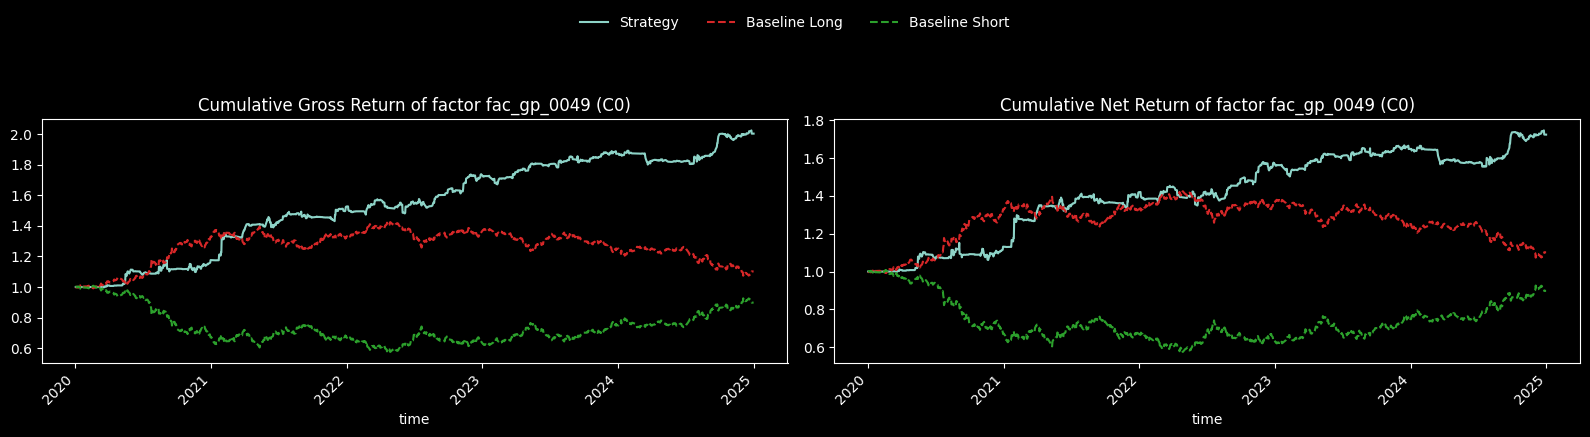

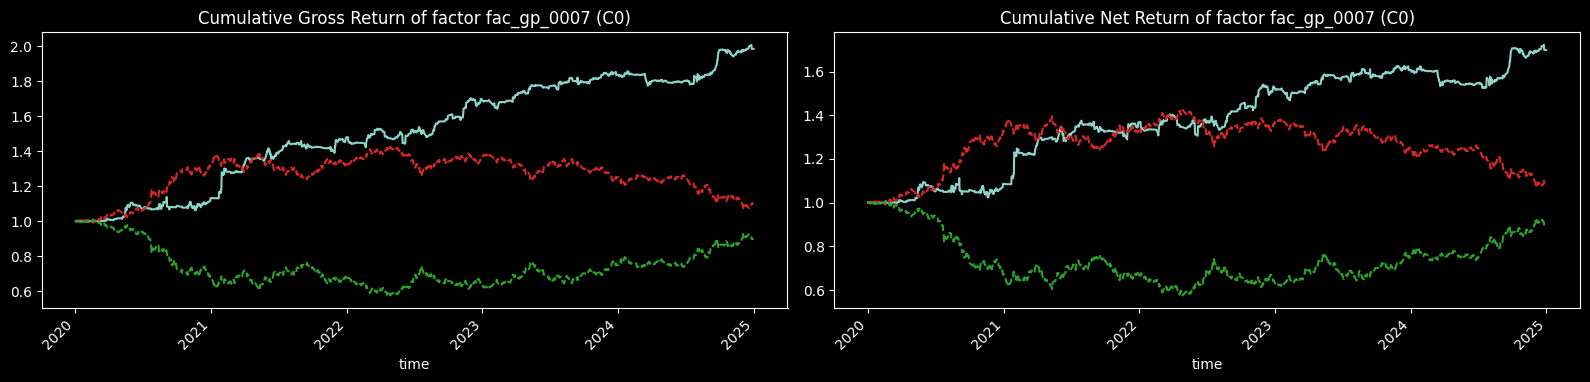

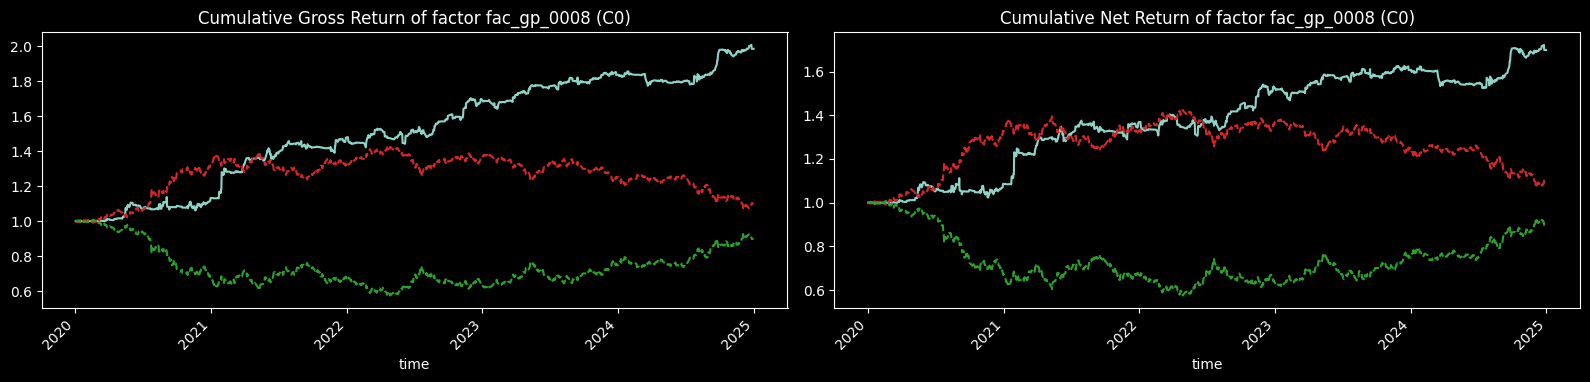

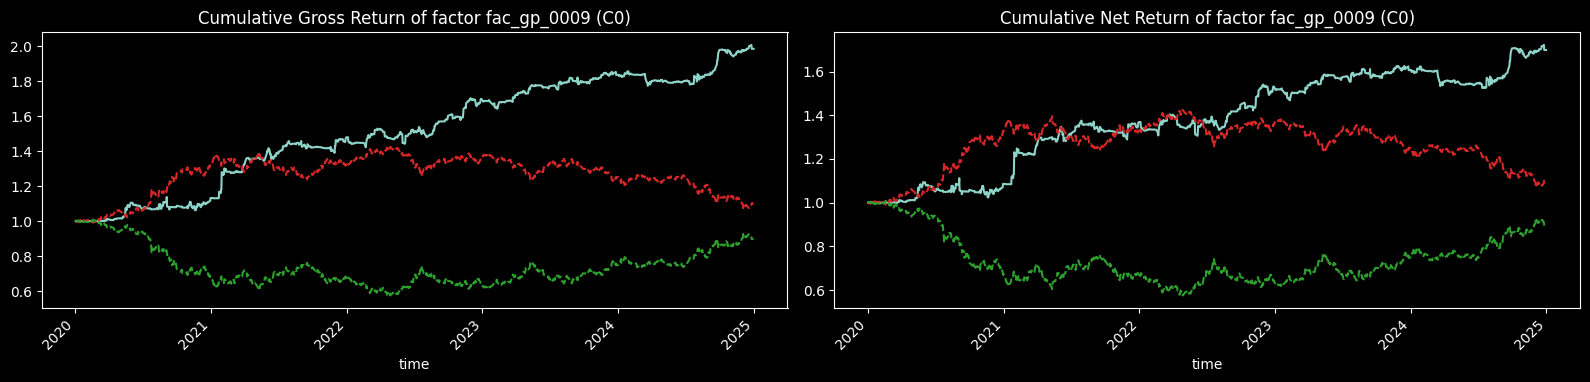

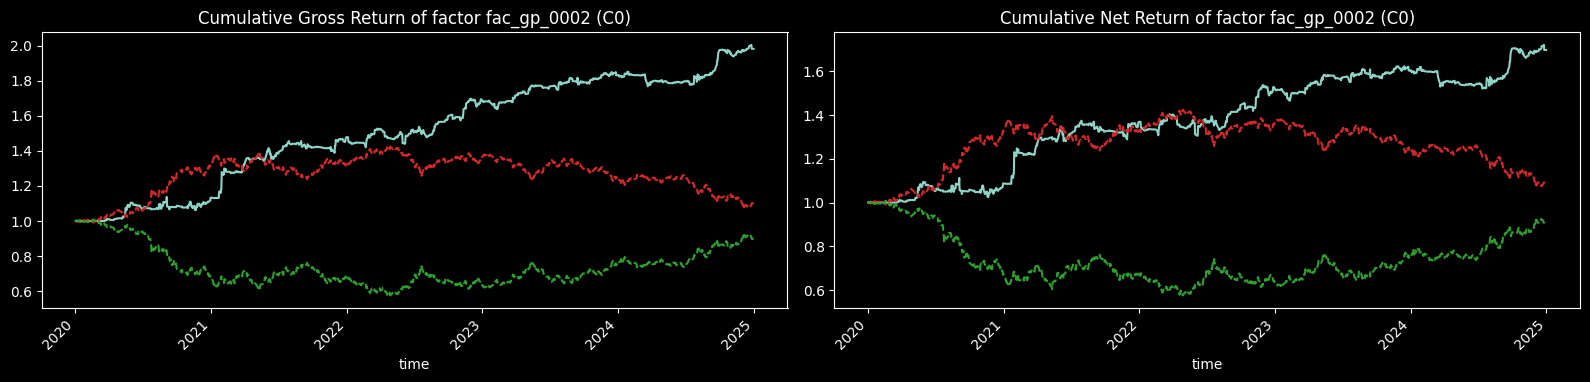

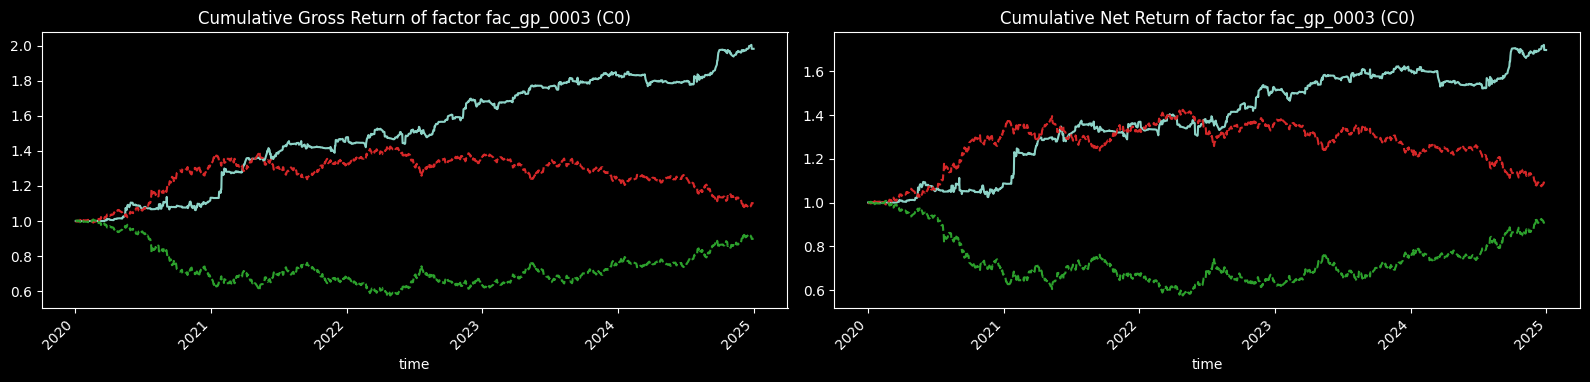

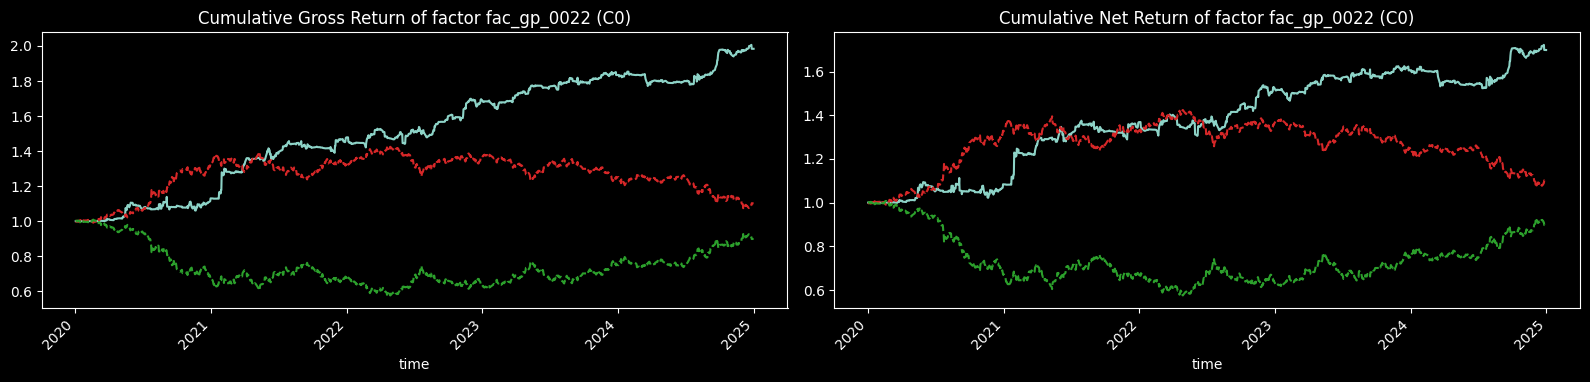

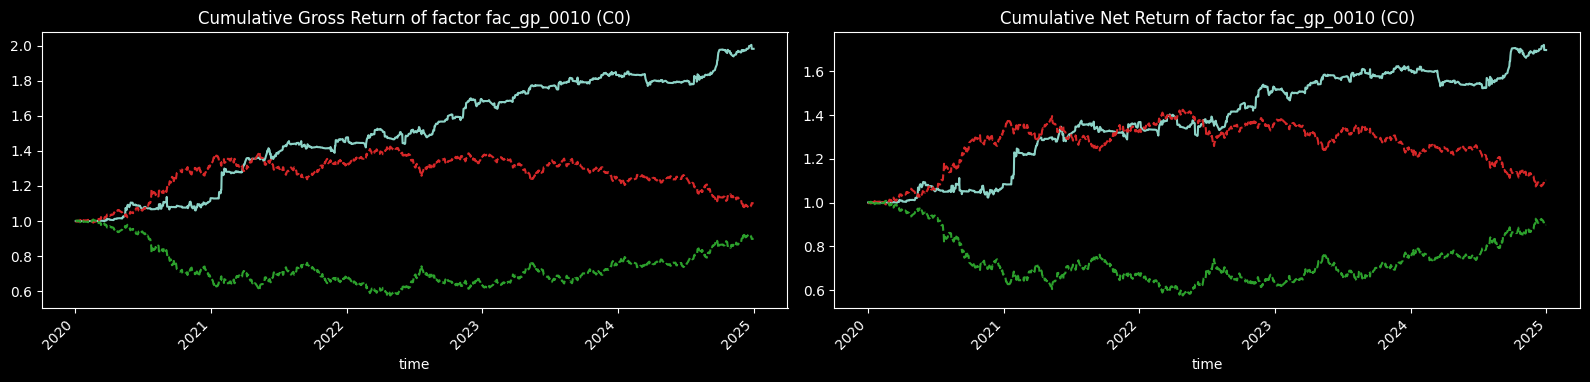

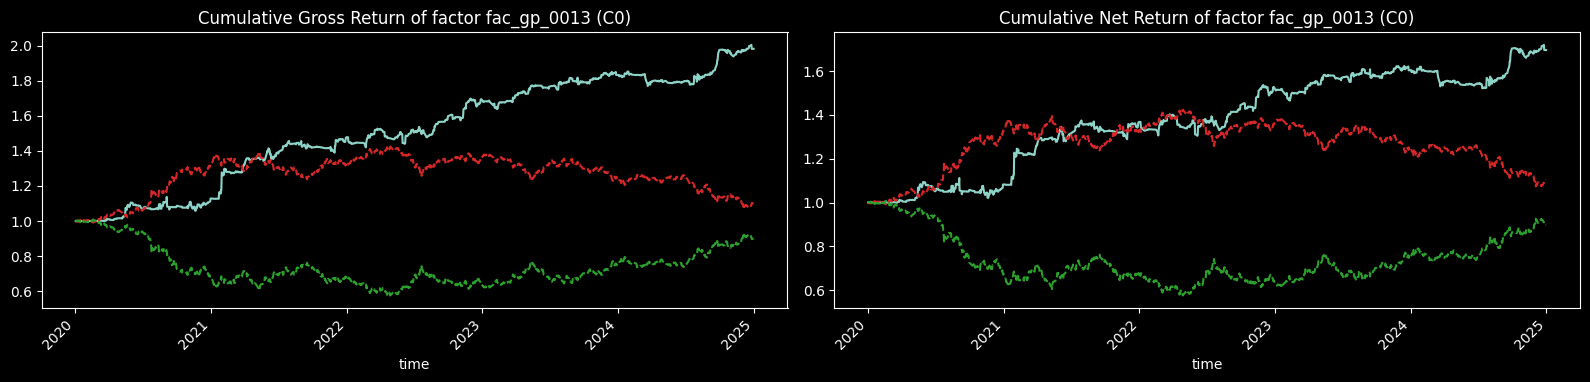

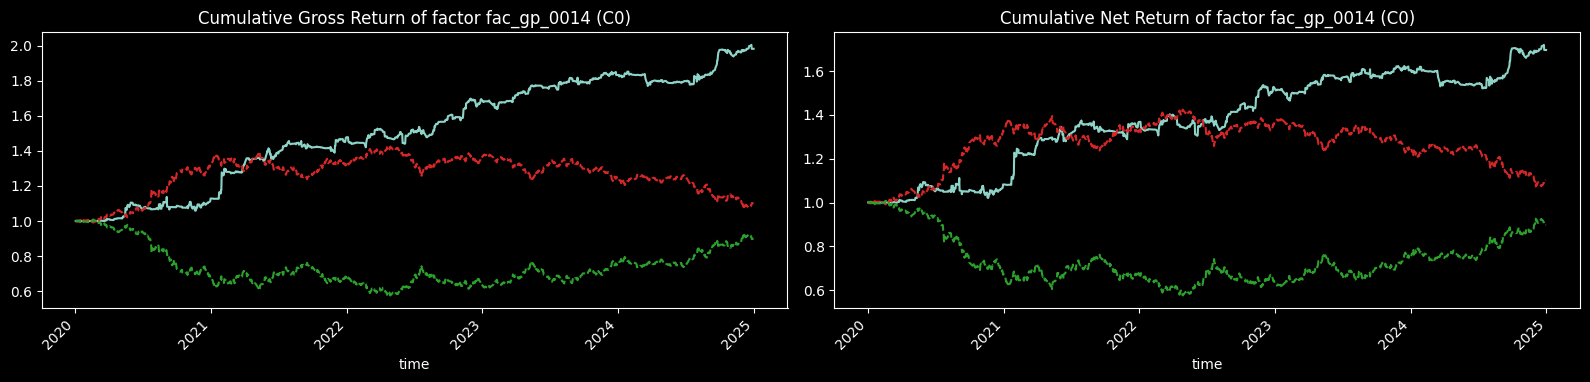

In [9]:
# 净值曲线
start_time = pd.to_datetime('20200101')
end_time = pd.to_datetime('20241231')
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=top_fc_name, show_baseline=True)

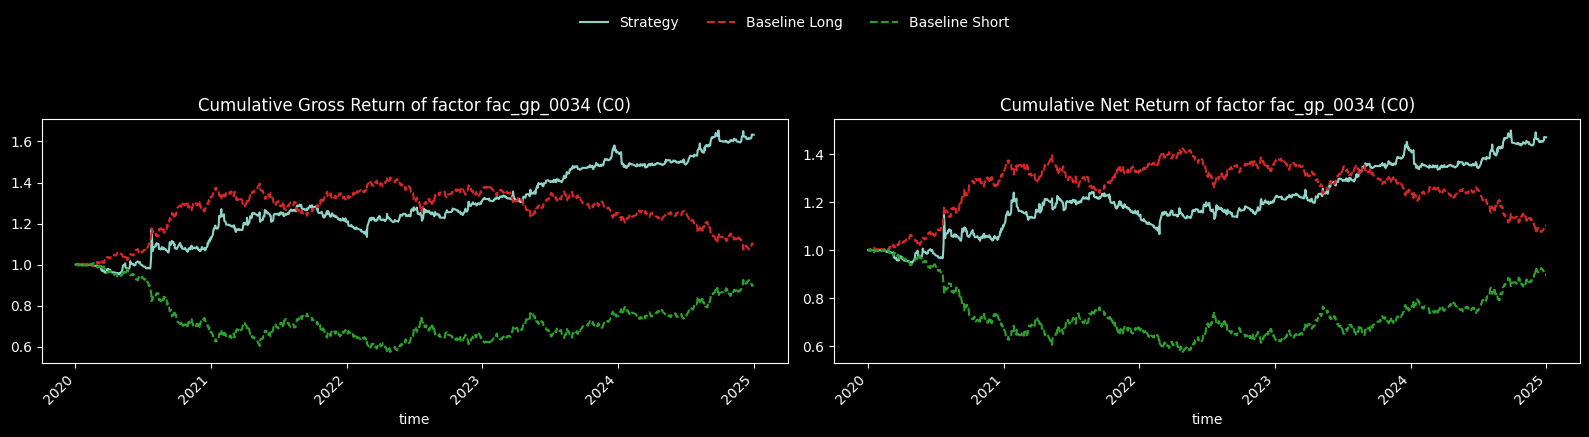

In [10]:
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=selected_fc_name_list, show_baseline=True)

In [ ]:
from datetime import datetime

In [ ]:
date_str = datetime.now().strftime('%Y%m%d')
date_str